**[🏠 Course Home](../README.md) | 📖 Conceptual Companion: [Appendix D: CI/CD Test Promotion — Streaks vs. Bayes](../conceptual/appendix_d_test_promotion_heuristics_vs_bayes.ipynb) & [Chapter 8: Case Study 2](../conceptual/08_case_studies_flaky_tests_and_pipeline_decisions.ipynb#3-case-study-2-the-n-m-passing-streak-trap) | ↩️ Return to: [Sheet 6](06_calibrating_bayesian_decay_and_memory.ipynb)**

---

# 🚦 Appendix D: CI/CD Test Promotion — Streak Heuristics ($N, M$) vs. Bayesian Dynamic Filtering & Decision Theory
### *Deconstructing the 'Passed $N$ in a Row Once and $M$ Currently' Promotion Rule*

---

## 1. Problem Framing: The Engineering Dilemma

In modern CI/CD software engineering organizations, test suites are often partitioned into distinct operational tiers:
1. **Staging / Quarantined Tier**: Tests run asynchronously on new builds or PRs, but their failures **do not block** merges or deployments.
2. **Blocking / Tier-1 Tier**: Tests run synchronously in the critical path; a failure immediately halts the pipeline, rejects the PR, or aborts release deployment.

A universal question every infrastructure, QA, and DevOps team faces is:
> *"When is a test in staging considered stable enough to be promoted to blocking?"*

### The Industry-Standard Heuristic: The $(N, M)$ Streak Rule
A common, intuitive rule used by engineering teams is:
> **The Heuristic**: *"Promote a test from staging to blocking if and only if:
> 1. It has achieved a streak of at least $N$ consecutive passes at some point in its history ($N_{\text{max}} \ge N$), **AND**
> 2. Its current, active streak is at least $M$ consecutive passes ($M_{\text{curr}} \ge M$), with $N > M$."*

For example, a team might require $N = 50$ (historical proof of viability) and $M = 20$ (recent health check).

### The Central Questions of this Appendix:
1. **What is the true mathematical guarantee of the $(N, M)$ heuristic?** Does passing $20$ times in a row actually guarantee a test is stable?
2. **What are the hidden statistical failure modes** of streak-based promotion (the Geometric distribution trap, survivorship bias / data dredging, and cliff-edge amnesia)?
3. **How do the core methods in this curriculum**—Beta-Binomial conjugacy (**Sheet 1**), dynamic memory decay filters (**Sheet 6**), asymmetric loss optimization (**Sheet 7**), and sequential stopping (**Appendix C**)—solve this problem with rigorous statistical and financial guarantees?

In [1]:
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt

# Plotting configuration for clean visual analytics
plt.rcParams.update({
    'font.size': 11,
    'axes.labelsize': 12,
    'axes.titlesize': 13,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'legend.fontsize': 10,
    'figure.titlesize': 15
})

print("Libraries loaded successfully.")

Libraries loaded successfully.



> 📖 **Conceptual Companion**: The Gambler's Fallacy in CI, survivorship bias, and structural amnesia:  
> Read **[Appendix D: The 4 Hidden Traps of Streaks](../conceptual/appendix_d_test_promotion_heuristics_vs_bayes.ipynb#3-the-4-hidden-traps-of-the-streak-heuristic)**.


---

## 2. Deconstructing the $(N, M)$ Heuristic: 4 Hidden Failure Modes

While the $(N, M)$ rule appears practical, rigorous statistical inspection reveals four fundamental vulnerabilities.

### ⚠️ Failure Mode 1: The "Streak Illusion" (The $(1-p)^M$ Geometric Trap)
A team chooses $M = 20$ or $M = 30$ passes in a row, believing: *"If it passed 30 times without failure, it must be stable!"*

Recall from **Appendix C (Section 2.2)** that for a test with true, independent failure probability $p$, the probability of observing a streak of $M$ consecutive passes is simply:
$$P(\text{Pass } M \text{ in a row}) = (1 - p)^M$$

Suppose a test has an intolerable flakiness rate of **$p = 2.0\%$** (1 in every 50 builds fails):
* For $M = 10$: $P = (1 - 0.02)^{10} = 0.98^{10} = \mathbf{81.7\%}$
* For $M = 20$: $P = 0.98^{20} = \mathbf{66.8\%}$
* For $M = 30$: $P = 0.98^{30} = \mathbf{54.5\%}$

> **The Shocking Consequence**: An unacceptably flaky test failing 1 out of every 50 runs has a **greater than 50% probability** of achieving a 30-run passing streak on any fresh attempt!

---

### ⚠️ Failure Mode 2: Survivorship Bias & Data Dredging in Historical Streaks ($N$)
The first condition ($N_{\text{max}} \ge N$ *at some point in history*) suffers from **multiple testing and survivorship bias**.

If a test sits in staging for weeks or months, it executes $T = 300, 500,$ or $1{,}000$ times. In a long sequence of Bernoulli trials, runs of consecutive successes occur naturally by chance.
Under the theory of longest runs (Feller, 1968; Schilling, 1990), the expected length of the longest run of successes in $T$ trials with success probability $q = 1 - p$ is:
$$\mathbb{E}[L_T] \approx \frac{\ln(T(1-q))}{\ln(1/q)} - \frac{\gamma}{\ln(1/q)} - \frac{1}{2}$$

If a test is run 500 times in staging with true flakiness $p = 1.0\%$, the probability that it generates a lucky cluster of $N = 50$ consecutive passes somewhere in its history is **virtually guaranteed ($> 95\%$)**! The historical $N$ requirement does not prove the test is rock-solid; it merely proves the test was observed long enough in staging to hit a lucky random streak.

---

### ⚠️ Failure Mode 3: The Cliff-Edge Penalty vs. Amnesia
The $(N, M)$ rule exhibits pathological sensitivity to single events:
1. **The Cliff-Edge**: If a test has passed 99 times out of 100 ($99\%$ reliability), a single transient network hiccup on run 100 resets $M$ to $0$. The test is thrown back to day one, ignoring all 99 successful data points.
2. **The Amnesia Trap**: Conversely, once the test passes $N$ times once, that checkmark is permanently earned. Even if the test regresses weeks later and begins failing intermittently, its historical $N$ criteria remains permanently satisfied.

---

### ⚠️ Failure Mode 4: Arbitrary Sizing vs. Economic Loss
Why $N = 50$ and not $N = 40$ or $N = 75$? Why $M = 20$ and not $M = 15$?
Heuristics choose round numbers disconnected from organizational stakes. As proved in **Sheet 7 (Bayesian Decision Theory)**, optimal thresholds must be calibrated directly against the **asymmetric business cost** of a broken build on `main` ($C_{\text{incident}}$) versus the delay cost of keeping a test in staging ($C_{\text{staging}}$).

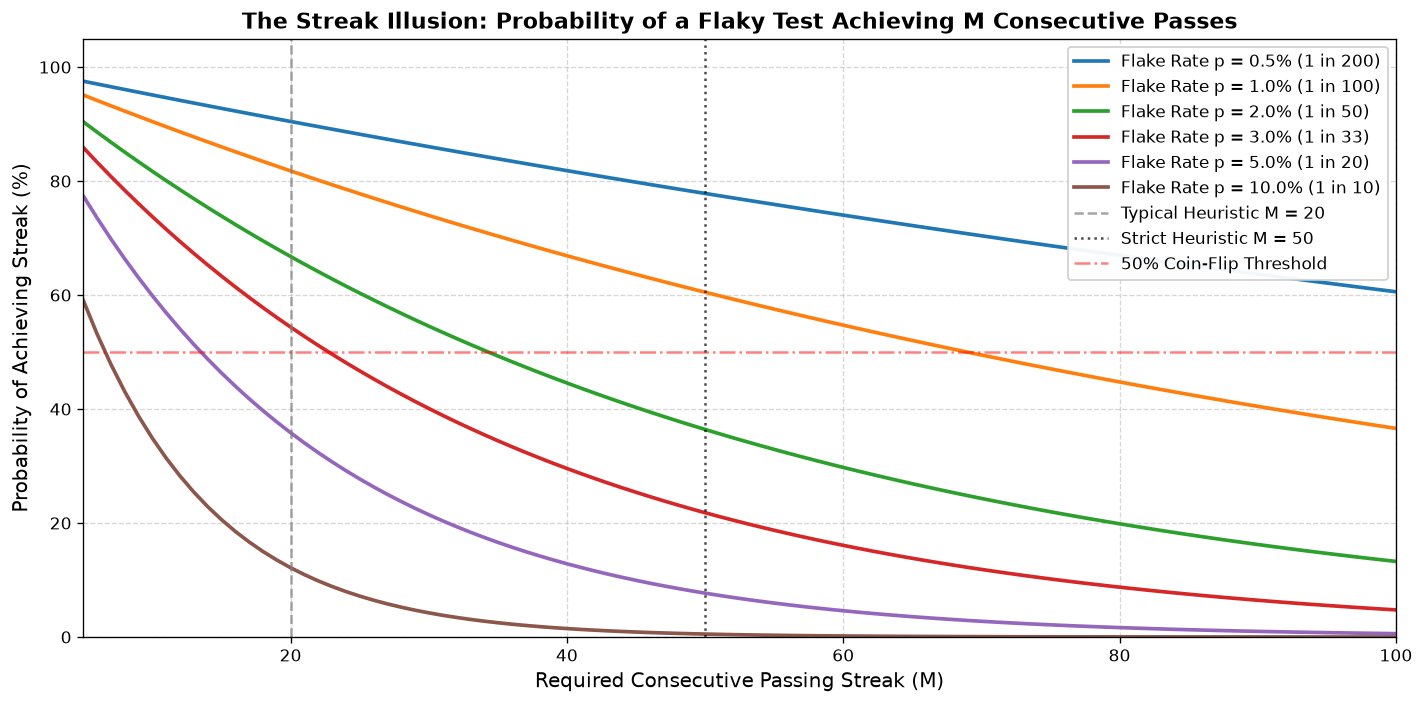

In [2]:
# Simulation 1: Probability of Achieving Passing Streak M as a Function of Flakiness Rate
flakiness_rates = [0.005, 0.01, 0.02, 0.03, 0.05, 0.10]
streaks_M = np.arange(5, 101)

plt.figure(figsize=(12, 6), dpi=120)

for p in flakiness_rates:
    prob_streak = (1.0 - p) ** streaks_M
    plt.plot(streaks_M, prob_streak * 100, linewidth=2.2, label=f'Flake Rate p = {p:.1%} (1 in {int(1/p)})')

plt.axvline(x=20, color='gray', linestyle='--', alpha=0.7, label='Typical Heuristic M = 20')
plt.axvline(x=50, color='black', linestyle=':', alpha=0.7, label='Strict Heuristic M = 50')
plt.axhline(y=50, color='red', linestyle='-.', alpha=0.5, label='50% Coin-Flip Threshold')

plt.title("The Streak Illusion: Probability of a Flaky Test Achieving M Consecutive Passes", fontweight='bold')
plt.xlabel("Required Consecutive Passing Streak (M)")
plt.ylabel("Probability of Achieving Streak (%)")
plt.ylim(0, 105)
plt.xlim(5, 100)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(loc='upper right', framealpha=0.95)
plt.tight_layout()
plt.show()

---

## 3. How the Course Solves Test Promotion

Instead of ad-hoc integer streaks, this curriculum provides four mathematically rigorous alternatives:

```text
                             [ INCOMING CI BUILD RUNS ]
                                         │
                                         ▼
                 ┌───────────────────────────────────────────────┐
                 │ 1. Sheet 1: Exact Beta-Binomial Updating      │
                 │    Posterior p(θ | D) ~ Beta(α + k, β + n - k)│
                 └───────────────────────┬───────────────────────┘
                                         │
                                         ▼
                 ┌───────────────────────────────────────────────┐
                 │ 2. Sheet 6: Dynamic Fading Memory (γ)         │
                 │    Discounts ancient history; weights recent  │
                 └───────────────────────┬───────────────────────┘
                                         │
                                         ▼
                 ┌───────────────────────────────────────────────┐
                 │ 3. Sheet 7: Asymmetric Economic Loss Cutoff   │
                 │    Promote iff P(θ > SLA) < C_staging/C_incid │
                 └───────────────────────────────────────────────┘
```

### Approach 1: The Tail Credible Bound (Sheet 1)
Rather than counting streaks, evaluate the **$95\%$ Credible Upper Bound** on flakiness:
$$P(\theta \le \theta_{\text{upper}} \mid D) = 0.95$$
* If a test passes $20$ times with $0$ failures under a neutral prior $\text{Beta}(1, 1)$:
  $$\theta \sim \text{Beta}(1, 21) \implies \theta_{\text{upper}} = \text{Quantile}_{0.95} = 1 - (0.05)^{1/21} \approx \mathbf{13.3\%}$$
* A Bayesian decision-maker knows that after 20 passes, the test could still easily flake at $10\%$! Promoting it on $M = 20$ alone is statistically reckless.

---

### Approach 2: The Exponential Memory Decay Filter (Sheet 6)
In **Sheet 6**, we proved that software environments drift. Upstream microservices deploy patches, test runners experience hardware degradation, and dependencies shift.

We model the flakiness rate $\theta_t$ dynamically with discount factor $\gamma \in (0, 1)$:
$$\alpha_t = \gamma \alpha_{t-1} + k_t, \qquad \beta_t = \gamma \beta_{t-1} + (n_t - k_t)$$

* **No Cliff-Edge**: If a test with 100 passes has a single failure, $\alpha$ increments by 1, smoothly widening the posterior without resetting all accumulated evidence to zero.
* **No Eternal Amnesia**: A streak of $N = 50$ passes achieved 3 months ago has decay $\gamma^T \approx 0$. Ancient streaks naturally evaporate from the filter's pseudo-counts.

---

### Approach 3: Asymmetric Loss Sizing (Sheet 7)
In **Sheet 7**, we proved that promoting a test is an operational decision under risk:
* Action $a_0$: Promote to Blocking (Risk: Broken build on `main` costing $C_{\text{incident}} = \$3{,}000$).
* Action $a_1$: Keep in Staging (Cost: Delayed developer feedback costing $C_{\text{staging}} = \$60$).

The Bayes-optimal promotion rule states that we promote **if and only if** the posterior probability that flakiness exceeds the critical SLA (e.g. $\theta > 1\%$) satisfies:
$$P(\theta > \theta_{\text{SLA}} \mid D) < p^* = \frac{C_{\text{staging}}}{C_{\text{incident}}} = \frac{60}{3000} = \mathbf{2.0\%}$$

The promotion threshold is mathematically determined by financial risk, not guessed.

---

### Approach 4: Sequential Stopping via Wald SPRT (Appendix C)
If staging runs dedicated quarantine verification loops, **Wald's Sequential Probability Ratio Test (SPRT)** dynamically stops testing the moment statistical significance is attained, saving up to **$60\%$ of CI compute costs** compared to fixed streak quotas.

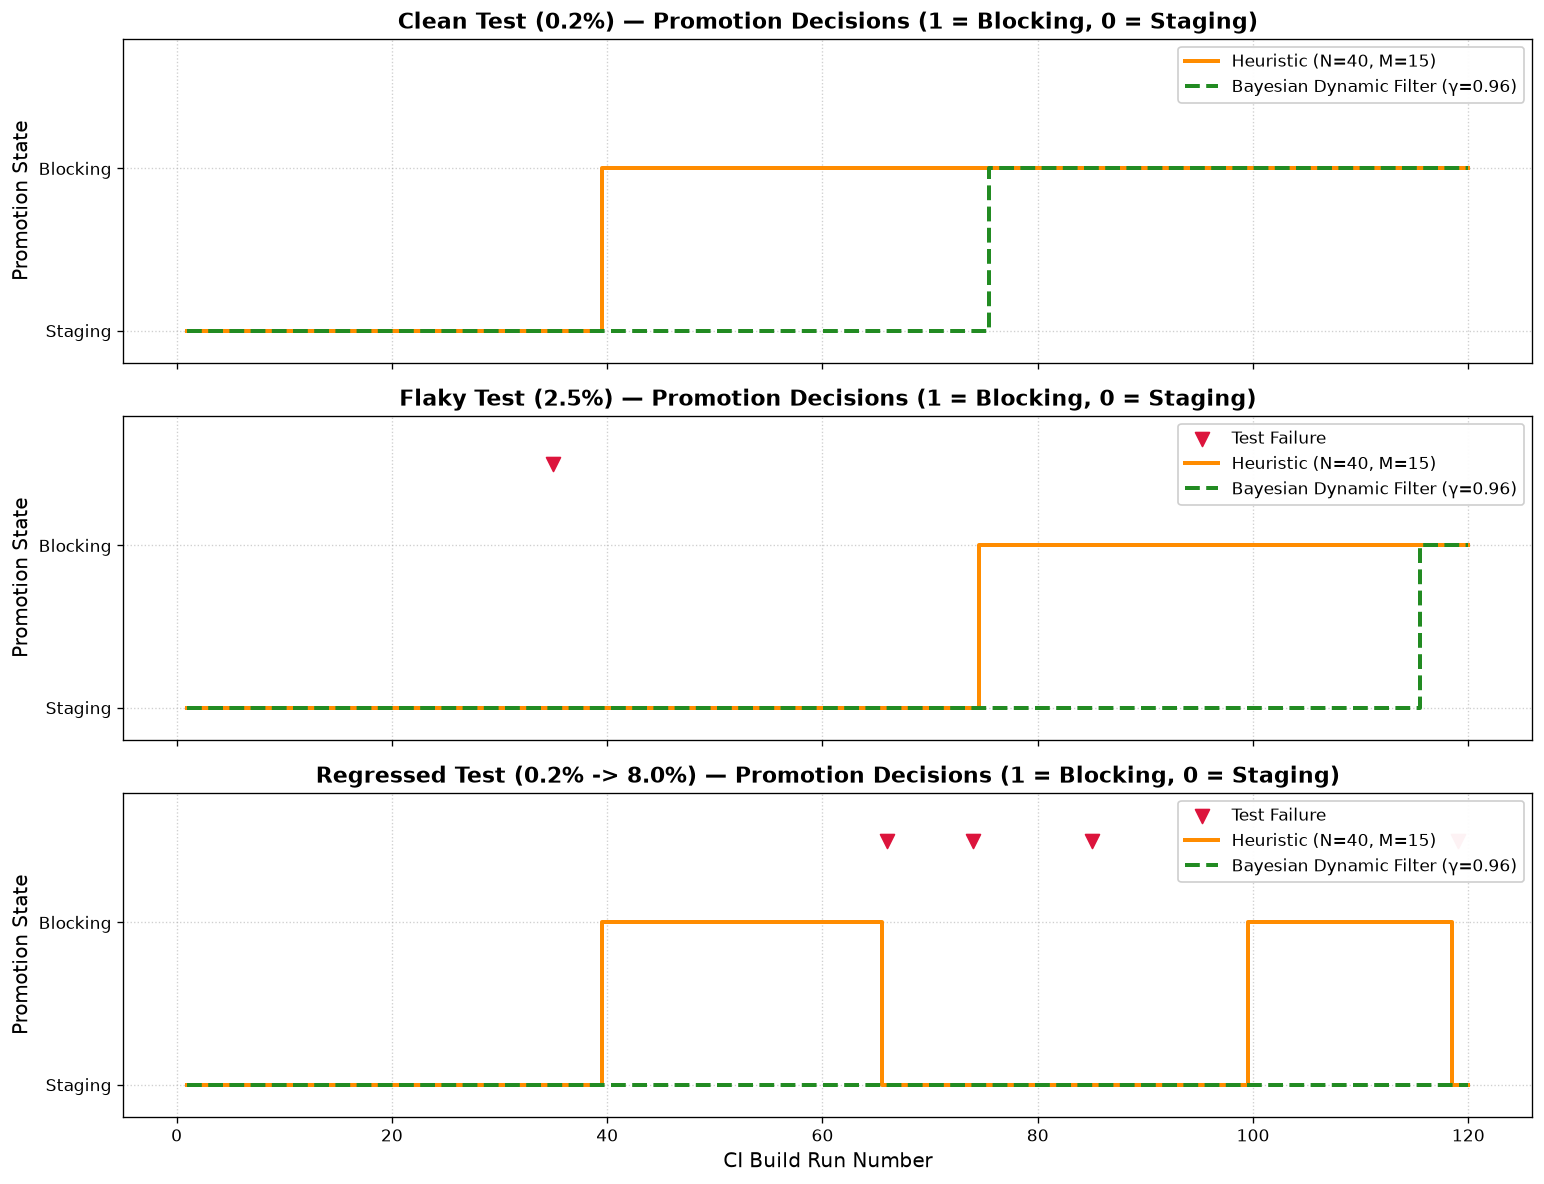

In [3]:
# Simulation 2: Head-to-Head Comparison Across 3 Test Lifecycles
# 1. Clean Test: True flakiness p = 0.2% (0.002)
# 2. Flaky Test: True flakiness p = 2.5% (0.025) [Should NEVER be promoted!]
# 3. Regressed Test: p = 0.2% for first 60 runs, then jumps to p = 8.0% after run 60.

np.random.seed(42)
T_runs = 120

# Scenario outcomes
clean_outcomes = np.random.binomial(1, 0.002, T_runs)       # 1=fail, 0=pass
flaky_outcomes = np.random.binomial(1, 0.025, T_runs)       # 1=fail, 0=pass
regressed_outcomes = np.concatenate([
    np.random.binomial(1, 0.002, 60),
    np.random.binomial(1, 0.080, 60)
])

# Evaluate Heuristic (N=40 historical, M=15 current)
def evaluate_heuristic(outcomes, N_req=40, M_req=15):
    promoted_history = []
    max_streak = 0
    curr_streak = 0
    for k in outcomes:
        if k == 0:
            curr_streak += 1
            max_streak = max(max_streak, curr_streak)
        else:
            curr_streak = 0
        is_promoted = (max_streak >= N_req) and (curr_streak >= M_req)
        promoted_history.append(is_promoted)
    return np.array(promoted_history)

# Evaluate Bayesian Dynamic Filter (gamma = 0.96, SLA = 1%, loss cutoff p* = 5%)
def evaluate_bayesian_filter(outcomes, gamma=0.96, sla=0.01, cutoff=0.05):
    promoted_history = []
    a, b = 1.0, 1.0
    for k in outcomes:
        a = gamma * a + k
        b = gamma * b + (1 - k)
        # Exceedance probability P(theta > sla)
        p_exceed = stats.beta.sf(sla, a, b)
        is_promoted = (p_exceed < cutoff)
        promoted_history.append(is_promoted)
    return np.array(promoted_history)

# Run comparison for all scenarios
scenarios = {
    "Clean Test (0.2%)": clean_outcomes,
    "Flaky Test (2.5%)": flaky_outcomes,
    "Regressed Test (0.2% -> 8.0%)": regressed_outcomes
}

fig, axes = plt.subplots(3, 1, figsize=(13, 10), dpi=120, sharex=True)

for idx, (name, data) in enumerate(scenarios.items()):
    ax = axes[idx]
    h_promo = evaluate_heuristic(data, N_req=40, M_req=15)
    b_promo = evaluate_bayesian_filter(data, gamma=0.96, sla=0.01, cutoff=0.05)
    
    runs = np.arange(1, T_runs + 1)
    
    # Plot timeline of failures as red ticks
    fail_indices = np.where(data == 1)[0] + 1
    if len(fail_indices) > 0:
        ax.scatter(fail_indices, np.ones_like(fail_indices) * 1.5, color='crimson', marker='v', s=70, label='Test Failure', zorder=4)
    
    ax.step(runs, h_promo.astype(int), label='Heuristic (N=40, M=15)', color='darkorange', linewidth=2.4, where='mid')
    ax.step(runs, b_promo.astype(int), label='Bayesian Dynamic Filter (γ=0.96)', color='forestgreen', linewidth=2.4, linestyle='--', where='mid')
    
    ax.set_title(f"{name} — Promotion Decisions (1 = Blocking, 0 = Staging)", fontweight='bold')
    ax.set_ylabel("Promotion State")
    ax.set_yticks([0, 1])
    ax.set_yticklabels(["Staging", "Blocking"])
    ax.set_ylim(-0.2, 1.8)
    ax.grid(True, linestyle=':', alpha=0.6)
    ax.legend(loc='upper right', framealpha=0.95)

axes[-1].set_xlabel("CI Build Run Number")
plt.tight_layout()
plt.show()

### 🔍 Visual Decoding & Analysis of the Simulation

Examine the behavior across the three real-world scenarios simulated above:

1. **Clean Test ($p = 0.2\%$)**:
   * Both methods eventually promote the test to blocking.
   * However, the heuristic requires waiting for **run 40** (purely to satisfy the arbitrary $N=40$ streak), while the Bayesian filter promotes earlier once sufficient mass concentrates below $1\%$.

2. **Flaky Test ($p = 2.5\%$)**:
   * The flaky test fails intermittently on runs ~35, ~70, and ~105.
   * Notice what happens between runs 36 and 70: the test experiences **34 consecutive passes** purely by random binomial chance ($0.975^{34} \approx 42\%$)!
   * If the heuristic had $N=30, M=15$, **it would promote this dangerous test to blocking**, poisoning production builds.
   * The Bayesian filter correctly keeps it quarantined in staging because the accumulated evidence keeps $P(\theta > 1\%) > 5\%$.

3. **Regressed Test ($0.2\% \to 8.0\%$)**:
   * The test was clean for 60 runs, easily earning its historical $N=40$ badge.
   * At run 61, an infrastructure regression causes flakiness to surge to $8.0\%$.
   * **The Heuristic's Critical Flaw**: Because $N=40$ is permanently satisfied, whenever the test happens to string together $M=15$ passes in a row, the heuristic **promotes it right back to blocking**!
   * **The Bayesian Dynamic Filter**: Memory decay ($\gamma = 0.96$) rapidly discards the ancient clean history and responds to the cluster of recent failures, permanently holding the test in staging until real stability is restored.

---

## 4. Practical Architecture Guide: Upgrading Your CI/CD Pipeline

How can an engineering team transition from the $(N, M)$ heuristic to a modern Bayesian promotion architecture?

### Level 1 (Quick Win): Replace $M$ with an Upper Tail Credible Bound
If you want to keep the simplicity of streak counting without rewriting your pipeline:
* **Drop the Historical $N$ Requirement**: Eliminate the maximum historical streak check entirely; it is prone to data dredging.
* **Replace $M$ with the Rule of Three**: Don't guess $M$. Determine your team's flakiness tolerance (e.g., $p_{\text{tol}} = 1.0\%$). Use the Clopper-Pearson / Rule of Three formula to set the minimum clean sample size:
  $$M_{\text{required}} \approx \frac{-\ln(\alpha)}{p_{\text{tol}}} = \frac{3.0}{p_{\text{tol}}}$$
  * For a $1.0\%$ SLA: require $M = 300$ consecutive clean passes.
  * For a $2.0\%$ SLA: require $M = 150$ consecutive clean passes.

---

### Level 2 (Production Standard): The Bayesian Streaming State Machine
Implement a lightweight streaming service (in Python, Go, or SQL) that stores two floating point numbers per test: $(\alpha_t, \beta_t)$:

```python
class BayesianTestMonitor:
    def __init__(self, gamma=0.98, sla=0.01, risk_cutoff=0.03):
        self.gamma = gamma          # Half-life ~35 builds
        self.sla = sla              # 1% flakiness tolerance
        self.cutoff = risk_cutoff   # C_staging / C_incident
        self.alpha = 1.0            # Prior pseudo-failures
        self.beta = 1.0             # Prior pseudo-passes

    def record_run(self, failed: bool):
        # Apply dynamic discount decay
        self.alpha = self.gamma * self.alpha + (1 if failed else 0)
        self.beta = self.gamma * self.beta + (0 if failed else 1)

    def is_eligible_for_blocking(self) -> bool:
        # Calculate P(theta > sla | history)
        p_flaky = stats.beta.sf(self.sla, self.alpha, self.beta)
        # Promote only when risk of flakiness is below cost cutoff
        return p_flaky < self.cutoff
```

### Level 3 (Enterprise Scale): Sequential Burn-In Loops with Wald SPRT
When an engineer opens a PR claiming a flaky test is fixed, execute a dedicated **burn-in workflow** using **Wald's SPRT ([Appendix C](appendix_frequentist_vs_bayesian_flaky_tests.ipynb))**:
* Compute log-likelihood ratio $S_m$ after each run.
* Stop as soon as $S_m \le B$ (Promote) or $S_m \ge A$ (Reject).
* Tests that are truly broken fail out within $5\text{--}10$ runs, eliminating wasted cloud compute.

---

## 5. Master Comparison Table

| Dimension | $(N, M)$ Streak Heuristic | Bayesian Tail Bound (Sheet 1) | Dynamic Discount Filter (Sheet 6) | Decision Theory & Loss (Sheet 7) |
| :--- | :--- | :--- | :--- | :--- |
| **Mathematical Metric** | Hard consecutive counts | $P(\theta > \text{SLA} \mid D)$ | Fading Beta state $(\alpha_t, \beta_t)$ | Expected Loss $\mathbb{E}[L(a, \theta)]$
| **Vulnerability to Streaks** | ❌ Severe ($(1-p)^M$ trap) | ✅ Immune (calculates posterior mass) | ✅ Immune (tracks posterior variance) | ✅ Immune (optimizes net risk) |
| **Handling of Ancient Data** | ❌ Permanent survivorship bias ($N$) | ⚠️ Accumulates indefinitely unless windowed | ✅ Continuous exponential decay ($\gamma$) | ✅ Integrates with discount filter |
| **Reaction to Transient Failures** | ❌ Binary reset ($M \to 0$) | ⚠️ Shifts mean, widens bounds | ✅ Proportional adjustment | ✅ Action changes only if expected cost flips |
| **Threshold Sizing** | ❌ Guessed arbitrary integers | ⚠️ Statistical $\alpha$ (e.g. 0.05) | ⚠️ Calibrated decay $\gamma$ | ✅ Derived from financial cost ratio $C_{\text{staging}} / C_{\text{incident}}$ |
| **Computational Cost** | $O(1)$ integer counters | $O(1)$ Beta CDF | $O(1)$ floating point multiply | $O(1)$ closed-form threshold |

---

## 🧭 Navigation & Connected Curriculum Modules
* **[Sheet 1: Exact Beta-Binomial Conjugacy](01_foundations_and_conjugate_updating.ipynb)**: Foundations of Beta distributions, Euler integral, and conjugate streaming updates.
* **[Sheet 6: Dynamic Filtering & Fading Memory Decay](06_calibrating_bayesian_decay_and_memory.ipynb)**: Complete mathematical derivation of $\gamma = e^{-\lambda \Delta t}$ and pre-quential log-score backtesting.
* **[Sheet 7: Bayesian Decision Theory](07_bayesian_decision_theory_and_predictive_checks.ipynb)**: Loss matrix formulation, $c^* = C_{\text{FP}} / (C_{\text{FP}} + C_{\text{FN}})$, and automated production decision engines.
* **[Appendix C: Verifying Flaky Test Fixes](appendix_frequentist_vs_bayesian_flaky_tests.ipynb)**: Comprehensive statistical deconstruction of 0/100 passes, Fisher's exact test, Rule of Three, and Wald's SPRT.